# Cyclistic Bike-Share Analysis
## Business Task
Determine how annual members and casual riders use Cyclistic bikes differently,
in order to inform a marketing strategy aimed at converting casual riders into annual members.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df_2019 = pd.read_csv("../cyclistic/data/Divvy_Trips_2019_Q1.csv")
df_2020 = pd.read_csv("../cyclistic/data/Divvy_Trips_2020_Q1.csv")


In [5]:
print(df_2019.shape)

(365069, 12)


In [6]:
print(df_2020.shape)

(426887, 13)


In [8]:
df_2019.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390.0,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441.0,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829.0,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,"1,783.0",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364.0,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0


In [9]:
df_2020.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,41.9671,-87.6674,member
1,8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,41.9542,-87.6644,member
2,789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117.0,41.9401,-87.6455,41.9402,-87.6530,member
3,C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24.0,41.8846,-87.6319,41.8918,-87.6206,member
4,943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212.0,41.8856,-87.6418,41.8899,-87.6343,member


In [10]:
df_2019 = df_2019.rename(columns={
    "trip_id": "ride_id",
    "start_time": "started_at",
    "end_time": "ended_at",
    "from_station_id": "start_station_id",
    "from_station_name": "start_station_name",
    "to_station_id": "end_station_id",
    "to_station_name": "end_station_name",
    "usertype": "member_casual"
})

df_2019["member_casual"] = df_2019["member_casual"].replace({
    "Subscriber": "member",
    "Customer": "casual"
})

print(df_2019.columns.tolist())

['ride_id', 'started_at', 'ended_at', 'bikeid', 'tripduration', 'start_station_id', 'start_station_name', 'end_station_id', 'end_station_name', 'member_casual', 'gender', 'birthyear']


In [11]:
# Keep only columns that exist in both datasets
cols = ["ride_id", "started_at", "ended_at", 
        "start_station_id", "start_station_name",
        "end_station_id", "end_station_name", "member_casual"]

df_2019 = df_2019[cols]
df_2020 = df_2020[cols]

# Merge into one dataframe
df = pd.concat([df_2019, df_2020], ignore_index=True)
print(df.shape)

(791956, 8)


In [12]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

df["ride_length"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60
df["day_of_week"] = df["started_at"].dt.day_name()

print(df[["started_at", "ride_length", "day_of_week", "member_casual"]].head())

           started_at  ride_length day_of_week member_casual
0 2019-01-01 00:04:37     6.500000     Tuesday        member
1 2019-01-01 00:08:13     7.350000     Tuesday        member
2 2019-01-01 00:13:23    13.816667     Tuesday        member
3 2019-01-01 00:13:45    29.716667     Tuesday        member
4 2019-01-01 00:14:52     6.066667     Tuesday        member


In [13]:
# Remove rides with negative or zero ride length (data errors)
df = df[df["ride_length"] > 0]

# Remove rides longer than 24 hours (likely bikes not returned)
df = df[df["ride_length"] < 1440]

print(f"Rows after cleaning: {df.shape[0]}")
print(f"Removed: {791956 - df.shape[0]} rows")

Rows after cleaning: 791264
Removed: 692 rows


In [14]:
df["member_casual"].value_counts()

member_casual
member    720126
casual     71138
Name: count, dtype: int64

In [15]:
df.groupby("member_casual")["ride_length"].mean().round(2)

member_casual
casual    36.46
member    11.41
Name: ride_length, dtype: float64

In [16]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_by_day = df.groupby(["member_casual", "day_of_week"])["ride_length"].mean().round(2)
avg_by_day = avg_by_day.unstack()
avg_by_day = avg_by_day[day_order]
avg_by_day


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
member_casual,,,,,,,
casual,28.75,32.61,37.80,32.43,34.96,38.95,40.86
member,11.10,11.32,11.17,11.07,11.10,12.44,12.92


In [17]:
ride_count_by_day = df.groupby(["member_casual", "day_of_week"])["ride_id"].count()
ride_count_by_day = ride_count_by_day.unstack()[day_order]
ride_count_by_day

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
member_casual,,,,,,,
casual,6672,7949,8328,7729,8466,13416,18578
member,110412,127946,121879,125198,115132,59381,60178


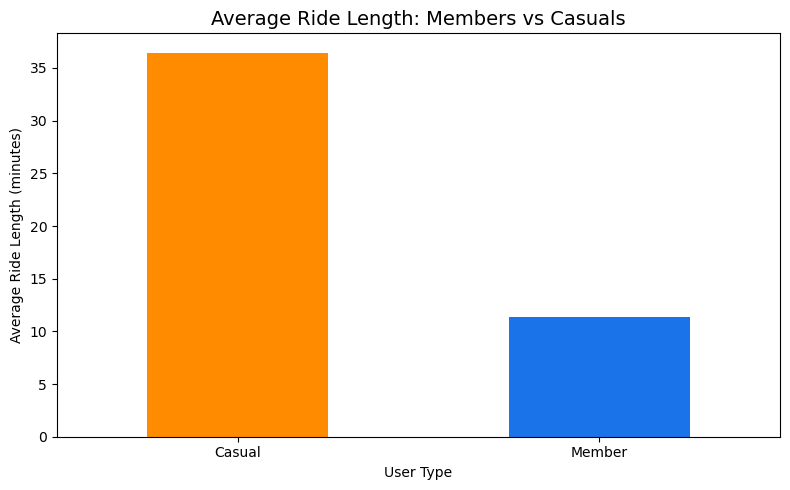

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("member_casual")["ride_length"].mean().plot(
    kind="bar", color=["#FF8C00", "#1A73E8"], ax=ax
)
ax.set_title("Average Ride Length: Members vs Casuals", fontsize=14)
ax.set_xlabel("User Type")
ax.set_ylabel("Average Ride Length (minutes)")
ax.set_xticklabels(["Casual", "Member"], rotation=0)
plt.tight_layout()
plt.show()

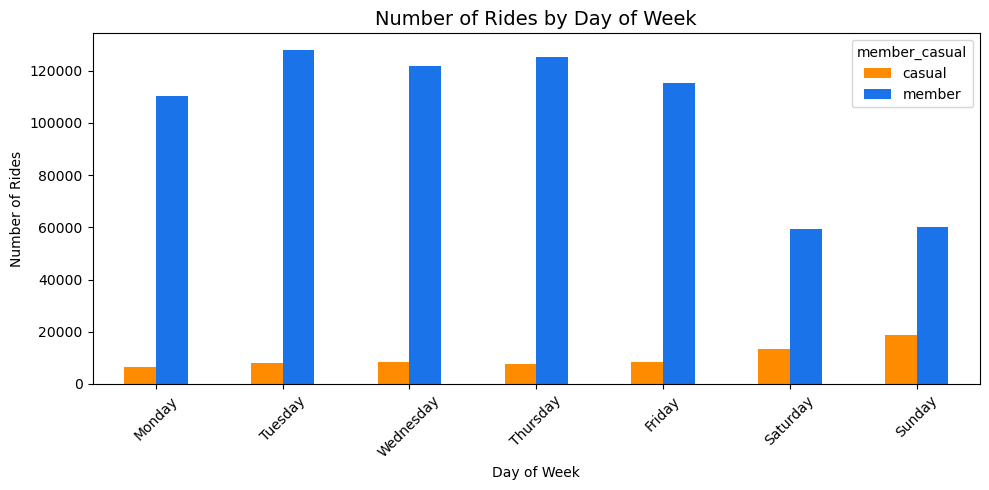

In [19]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, ax = plt.subplots(figsize=(10, 5))
ride_count_by_day.T.plot(kind="bar", color=["#FF8C00", "#1A73E8"], ax=ax)
ax.set_title("Number of Rides by Day of Week", fontsize=14)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Rides")
ax.set_xticklabels(day_order, rotation=45)
plt.tight_layout()
plt.show()

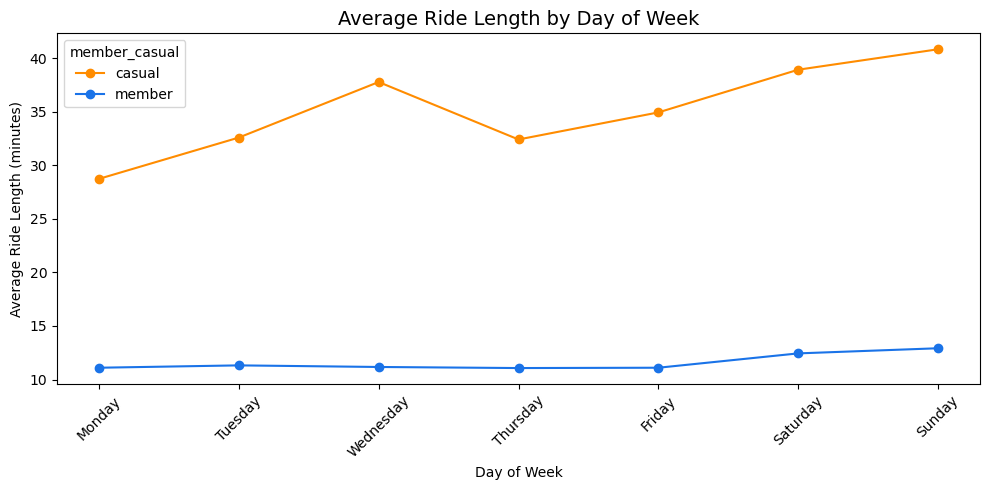

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
avg_by_day.T.plot(kind="line", color=["#FF8C00", "#1A73E8"], marker="o", ax=ax)
ax.set_title("Average Ride Length by Day of Week", fontsize=14)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Ride Length (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Findings

1. **Casual riders take much longer trips** — averaging 36 minutes vs 11 minutes for members (3x longer).

2. **Members ride consistently on weekdays** — peaking Tuesday-Thursday, suggesting commuter use.

3. **Casual riders spike on weekends** — Sunday is their busiest day, strongly suggesting leisure use.

## Top 3 Recommendations

1. **Launch a weekend membership promotion** — target casual riders when they are most active (Saturday/Sunday) with a discounted annual membership offer.

2. **Highlight commuter benefits in marketing** — show casuals how a membership saves money if they ride regularly, not just on weekends.

3. **Create a "leisure to commuter" campaign** — use digital ads on weekends to reach casual riders and show them the value of upgrading to a membership for their everyday travel.

In [22]:
df.to_csv("../cyclistic/data/cyclistic_cleaned.csv", index=False)
print("Cleaned data saved!")

Cleaned data saved!
